# 🌾 Complete ML Pipeline: Training → Vertex AI → Earth Engine

## Rice Planting Method Classification (Direct Seeding vs Transplanting)

**Complete Workflow:**
1. 📊 Data Loading & Preprocessing
2. 🏗️ Model Architecture (CNN-LSTM)
3. 🎯 Training with Early Stopping
4. 💾 Save Model Checkpoint
5. 🔄 Convert to TorchScript (Vertex AI format)
6. ☁️ Deploy to Vertex AI
7. 🌍 Connect to Earth Engine
8. 🚀 Large-scale Inference

---

## 📦 Install Dependencies

In [ ]:
# Install required packages
!pip install -q rasterio torchmetrics statsmodels optuna scikit-image
!pip install -q google-cloud-storage google-cloud-aiplatform earthengine-api

## 📚 Import Libraries

In [ ]:
import os
import glob
import random
import tarfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import layers, Model, optimizers

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torchmetrics import Accuracy, Precision, Recall, F1Score

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

import google.auth
from google.cloud import storage
from google.cloud import aiplatform
from google.colab import auth

random.seed(42)

print("✓ All libraries imported successfully")

✓ All libraries imported successfully


In [ ]:
# Check GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [ ]:
auth.authenticate_user()

## ⚙️  Configuration

In [ ]:
# Google Cloud Settings
PROJECT_ID = 'sensesaka2024'
REGION = 'asia-southeast1'
BUCKET_NAME = 'leads-agri'

# Model Settings
MODEL_NAME = 'lstm-planting-method'
SEASON_TYPE = 'dry'  # 'dry' or 'wet'

SEQUENCE_LENGTH = 18  # Number of timesteps
HIDDEN_DIM = 64
NUM_CLASSES = 2
DROPOUT_RATE = 0.3
BANDS = [f"{i}_VH" for i in range(18)]

# Training settings
BATCH_SIZE = 32
EPOCHS = 100
LEARNING_RATE = 0.001

# Paths
DATA_PATH = '/content/drive/MyDrive/AI-PlantingMethod/data/csv/*_Dry-Season.csv'
MODEL_SAVE_PATH = '/content/drive/MyDrive/AGRI/Planting_Method/models'
VERTEX_MODEL_PATH = f'models/planting/dry/{MODEL_NAME}'
LOCAL_MODEL_DIR = 'saved_model_tf'
MODEL_DIR = f'gs://{BUCKET_NAME}/models/planting/dry/lstm_wrapped_test'

os.makedirs(MODEL_SAVE_PATH, exist_ok=True)
os.makedirs(LOCAL_MODEL_DIR, exist_ok=True)

print(f"Project: {PROJECT_ID}, Model: {MODEL_NAME}, Season: {SEASON_TYPE}")

Project: sensesaka2024, Model: lstm-planting-method, Season: dry


## 📊 Data Loading & Preprocessing

In [ ]:
# ============================================
# LOAD DATA
# ============================================

csv_files = glob.glob(DATA_PATH)
df_list = []

for file in csv_files:
    temp_df = pd.read_csv(file)
    df_list.append(temp_df)
    print(f"Loaded {os.path.basename(file)}: {len(temp_df)} rows")

df_Train = pd.concat(df_list, ignore_index=True)
print(f"\nTotal samples: {len(df_Train)}")

# Extract features and labels
feature_cols = [col for col in df_Train.columns if col.endswith('_VH')]
X = df_Train[feature_cols].values
y = df_Train['crop_est_m'].apply(lambda x: 0 if x == 'Direct-Seeded' else 1).values

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Convert to dict of shape (batch, 1, 1, 1) for each band
X_train_dict = {b: X_train[:, i].reshape(-1, 1, 1, 1).astype(np.float32) for i, b in enumerate(BANDS)}
X_test_dict = {b: X_test[:, i].reshape(-1, 1, 1, 1).astype(np.float32) for i, b in enumerate(BANDS)}

# Create dataset
train_dataset = tf.data.Dataset.from_tensor_slices((X_train_dict, y_train)).batch(32).prefetch(tf.data.AUTOTUNE)
test_dataset = tf.data.Dataset.from_tensor_slices((X_test_dict, y_test)).batch(32).prefetch(tf.data.AUTOTUNE)

classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, weights))

print(class_weights)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Class distribution: {np.bincount(y)}")


Loaded reflectance_2025_Dry-Season.csv: 1067 rows
Loaded reflectance_2024_Dry-Season.csv: 1579 rows

Total samples: 2646
{np.int64(0): np.float64(1.5862068965517242), np.int64(1): np.float64(0.7301587301587301)}
Train: (2116, 18), Test: (530, 18)
Class distribution: [ 834 1812]


## 🏗️ Model Architecture

In [ ]:
# Alternative: Using GlobalAveragePooling2D instead of squeeze
def create_model(num_features, num_classes):
    """
    Alternative version using GlobalAveragePooling2D
    """
    inputs = keras.Input(
        shape=(1, 1, num_features),
        name='input_1'
    )

    # Use GlobalAveragePooling2D to safely remove spatial dimensions
    x = layers.GlobalAveragePooling2D()(inputs)  # (batch, num_features)

    # Expand dims for Conv1D
    x = layers.Reshape((num_features, 1))(x)  # (batch, num_features, 1)

    # CNN layers
    x = layers.Conv1D(filters=64, kernel_size=3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)

    x = layers.Conv1D(filters=128, kernel_size=3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)

    # LSTM layers
    x = layers.Bidirectional(layers.LSTM(64, return_sequences=True))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)

    x = layers.Bidirectional(layers.LSTM(32, return_sequences=False))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)

    # Dense layers
    x = layers.Dense(64, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = keras.Model(inputs, outputs, name='cnn_lstm_model')
    return model

NUM_FEATURES = len(BANDS)  # Assuming BANDS contains your feature names
model = create_model(NUM_FEATURES, NUM_CLASSES)
model.summary()

Model: "cnn_lstm_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_1 (InputLayer)            │ (None, 1, 1, 18)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_10     │ (None, 18)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_21 (Reshape)            │ (None, 18, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_24 (Conv1D)              │ (None, 18, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_143         │ (None, 18, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_116 (Dropout)           │ (None, 18, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_25 (Conv1D)              │ (None, 18, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_144         │ (None, 18, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_117 (Dropout)           │ (None, 18, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_24                │ (None, 18, 128)        │        98,816 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_145         │ (None, 18, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_118 (Dropout)           │ (None, 18, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_25                │ (None, 64)             │        41,216 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_146         │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_119 (Dropout)           │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_147         │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_120 (Dropout)           │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 171,074 (668.26 KB)

 Trainable params: 170,178 (664.76 KB)

 Non-trainable params: 896 (3.50 KB)

In [ ]:
print("\n Creating complete Earth Engine model...")
# ============================================
# Create the preprocessing layer
# ============================================

class TrainingModel(keras.Model):
    """Wrapper ONLY for training - handles dict input"""

    def __init__(self, preprocessing, backbone, **kwargs):
        super().__init__(**kwargs)
        self.preprocessing = preprocessing
        self.backbone = backbone

    def call(self, features_dict):
        # Stack bands: (B, 1, 1, 18)
        x = self.preprocessing(features_dict)
        # Apply model: (B, 1, 1, 18) → (B, 2)
        return self.backbone(x)

    def get_config(self):
        return super().get_config()

class MyPreprocessing(keras.layers.Layer):
    def __init__(self, **kwargs):
        super(MyPreprocessing, self).__init__(**kwargs)

    def call(self, features_dict):
        # Stack: {band: (B,1,1,1)} → (B,1,1,18)
        return tf.concat([features_dict[b] for b in BANDS], axis=-1)

    def get_config(self):
        config = super().get_config()
        config.update({'bands': BANDS})
        return config

class EarthEngineModel(keras.Model):
    def __init__(self, preprocessing, backbone, **kwargs):
        super().__init__(**kwargs)
        self.preprocessing = preprocessing
        self.backbone = backbone

    def call(self, features_dict):
        # Stack: (B,H,W,18)
        x = self.preprocessing(features_dict)

        batch_size = tf.shape(x)[0]
        height = tf.shape(x)[1]
        width = tf.shape(x)[2]

        # Reshape: (B*H*W, 1, 1, 18)
        x = tf.reshape(x, [-1, 1, 1, len(BANDS)])

        # Apply model: (B*H*W, 2)
        predictions = self.backbone(x)

        # Reshape back: (B, H, W, 2)
        return tf.reshape(predictions, [batch_size, height, width, NUM_CLASSES])

    def get_config(self):
        return super().get_config()

#wrapped_model = MyModel(MyPreprocessing(), model)
#wrapped_model = MyModel(MyPreprocessing(), model)

preprocessing = MyPreprocessing()
training_model = TrainingModel(preprocessing, model, name='training_model')


 Creating complete Earth Engine model...


## 🎯 Training Setup

In [ ]:
print("\n5. Compiling...")

training_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("✓ Compiled")

print("\n6. Training...")

history = training_model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=50,
    class_weight=class_weights,
    callbacks=[
        keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(patience=5, factor=0.5)
    ]
)

print("\n✓ Training complete!")


5. Compiling...
✓ Compiled

6. Training...
Epoch 1/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.4531 - loss: 0.7067 - val_accuracy: 0.4509 - val_loss: 0.6938 - learning_rate: 0.0010
Epoch 2/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.5486 - loss: 0.7030 - val_accuracy: 0.3245 - val_loss: 0.7063 - learning_rate: 0.0010
Epoch 3/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.5514 - loss: 0.7020 - val_accuracy: 0.3151 - val_loss: 0.7324 - learning_rate: 0.0010
Epoch 4/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.4631 - loss: 0.6970 - val_accuracy: 0.3472 - val_loss: 0.7353 - learning_rate: 0.0010
Epoch 5/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.4936 - loss: 0.6943 - val_accuracy: 0.3679 - val_loss: 0.7136 - learning_rate: 0.0010
Epoch 6/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.5144 - loss: 0.6953 - val_accuracy: 0.4000 - val_loss: 0.7280 - learning_rate: 0.0010
Epoch 7/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step

In [ ]:
test_loss, test_acc = training_model.evaluate(X_test_dict, y_test, verbose=0)
print(f"Test Accuracy: {test_acc:.4f}, Test Loss: {test_loss:.4f}")

print("\n8. Saving base model...")

# Save ONLY the base model (not the training wrapper)
model.save('/content/cnn_lstm_base_trained.h5')

print("✓ Base model saved to: /content/cnn_lstm_base_trained.h5")

print("\n" + "="*70)
print("✅ TRAINING COMPLETE!")
print("="*70)
print("\nNext step: Run the Earth Engine deployment script")
print("It will load this trained base model and add EE wrappers")

Test Accuracy: 0.6660, Test Loss: 0.6016

8. Saving base model...
✓ Base model saved to: /content/cnn_lstm_base_trained.h5

✅ TRAINING COMPLETE!

Next step: Run the Earth Engine deployment script
It will load this trained base model and add EE wrappers


In [ ]:
# ============================================
# 1. LOAD TRAINED BASE MODEL
# ============================================

print("\n1. Loading trained model...")

base_model = keras.models.load_model('/content/cnn_lstm_base_trained.h5')

print("✓ Trained model loaded")

preprocessing = MyPreprocessing()
ee_model = EarthEngineModel(preprocessing, base_model, name='ee_model')

# Test
test_input = {band: tf.random.normal([1, 3, 3, 1]) for band in BANDS}
output = ee_model(test_input)
print(f"✓ Test passed: {output.shape}")


1. Loading trained model...
✓ Trained model loaded
✓ Test passed: (1, 3, 3, 2)


In [ ]:
# ============================================
# TRAIN MODEL
# ============================================

wrapped_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


history = wrapped_model.fit(
    train_dataset,
    class_weight=class_weights,
    epochs=20,
    batch_size=BATCH_SIZE,
    verbose=1
)


test_loss, test_acc = wrapped_model.evaluate(X_test_dict, y_test, verbose=0)
print(f"Test Accuracy: {test_acc:.4f}, Test Loss: {test_loss:.4f}")

Epoch 1/20
{'0_VH': <tf.Tensor 'Cast:0' shape=(None, 1, 1, 1) dtype=float32>, '1_VH': <tf.Tensor 'Cast_9:0' shape=(None, 1, 1, 1) dtype=float32>, '2_VH': <tf.Tensor 'Cast_10:0' shape=(None, 1, 1, 1) dtype=float32>, '3_VH': <tf.Tensor 'Cast_11:0' shape=(None, 1, 1, 1) dtype=float32>, '4_VH': <tf.Tensor 'Cast_12:0' shape=(None, 1, 1, 1) dtype=float32>, '5_VH': <tf.Tensor 'Cast_13:0' shape=(None, 1, 1, 1) dtype=float32>, '6_VH': <tf.Tensor 'Cast_14:0' shape=(None, 1, 1, 1) dtype=float32>, '7_VH': <tf.Tensor 'Cast_15:0' shape=(None, 1, 1, 1) dtype=float32>, '8_VH': <tf.Tensor 'Cast_16:0' shape=(None, 1, 1, 1) dtype=float32>, '9_VH': <tf.Tensor 'Cast_17:0' shape=(None, 1, 1, 1) dtype=float32>, '10_VH': <tf.Tensor 'Cast_1:0' shape=(None, 1, 1, 1) dtype=float32>, '11_VH': <tf.Tensor 'Cast_2:0' shape=(None, 1, 1, 1) dtype=float32>, '12_VH': <tf.Tensor 'Cast_3:0' shape=(None, 1, 1, 1) dtype=float32>, '13_VH': <tf.Tensor 'Cast_4:0' shape=(None, 1, 1, 1) dtype=float32>, '14_VH': <tf.Tensor 'Cast_

ValueError: Argument `output` must have rank (ndim) `target.ndim - 1`. Received: target.shape=(None,), output.shape=(None, 1, 1, 2)

In [ ]:
print(ee_model.summary())

Model: "ee_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ my_preprocessing_46             │ ?                      │             0 │
│ (MyPreprocessing)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cnn_lstm_model (Functional)     │ (None, 2)              │       171,074 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 171,074 (668.26 KB)

 Trainable params: 170,178 (664.76 KB)

 Non-trainable params: 896 (3.50 KB)

None


## 🎯 Serialization

In [ ]:
# ============================================
# Add serialization/deserialization layers
# ============================================

print("\n5. Adding serialization layers...")

class DeSerializeInput(tf.keras.layers.Layer):
    """Deserialize base64 inputs from Earth Engine"""

    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def call(self, inputs_dict):
        """
        Args:
            inputs_dict: {band: (batch,) strings}
        Returns:
            {band: (batch, H, W, 1) floats}
        """
        return {
            k: tf.map_fn(
                lambda x: tf.io.parse_tensor(tf.io.decode_base64(x), tf.float32),
                v,
                fn_output_signature=tf.float32
            )
            for k, v in inputs_dict.items()
        }

    def compute_output_spec(self, inputs_dict):
        from keras import KerasTensor
        return {
            k: KerasTensor(shape=(None, None, None, 1), dtype=tf.float32, name=k)
            for k in inputs_dict.keys()
        }

    def get_config(self):
        return super().get_config()


class ReSerializeOutput(tf.keras.layers.Layer):
    """Serialize outputs back to base64 for Earth Engine"""

    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def call(self, output_tensor):
        """
        Args:
            output_tensor: (batch, H, W, n_classes)
        Returns:
            (batch,) strings
        """
        return tf.map_fn(
            lambda x: tf.io.encode_base64(tf.io.serialize_tensor(x)),
            output_tensor,
            fn_output_signature=tf.string
        )

    def compute_output_spec(self, output_tensor):
        from keras import KerasTensor
        return KerasTensor(shape=(None,), dtype=tf.string)

    def get_config(self):
        return super().get_config()

input_deserializer = DeSerializeInput()
output_serializer = ReSerializeOutput()

print("✓ Serialization layers created")

# ============================================
# BUILD FINAL MODEL
# ============================================

print("\n6. Building final model...")

# Serialized inputs (what Vertex AI receives)
serialized_inputs = {
    band: tf.keras.Input(shape=[], dtype='string', name=band)
    for band in BANDS
}

# Build pipeline
deserialized = input_deserializer(serialized_inputs)
predictions = ee_model(deserialized)
serialized_output = output_serializer(predictions)

# Final model
final_model = tf.keras.Model(serialized_inputs, serialized_output, name='final_model')

print("✓ Final model built")


5. Adding serialization layers...
✓ Serialization layers created

6. Building final model...
✓ Final model built


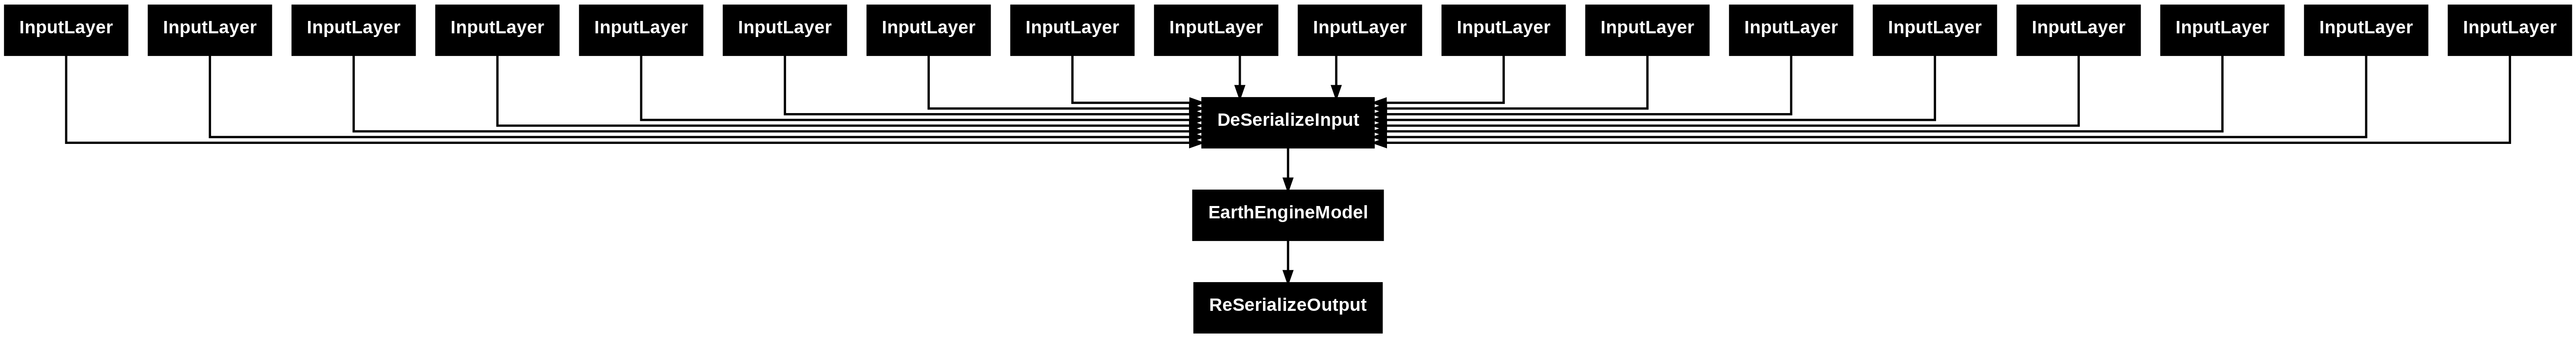

In [ ]:
tf.keras.utils.plot_model(final_model)

## 🔐 Authenticate with Google Cloud

In [ ]:
# Authenticate
auth.authenticate_user()

# Set project
!gcloud config set project {PROJECT_ID}

# Initialize Vertex AI
aiplatform.init(project=PROJECT_ID, location=REGION)

print(f"✓ Authenticated with project: {PROJECT_ID}")
print(f"✓ Region: {REGION}")

Updated property [core/project].
✓ Authenticated with project: sensesaka2024
✓ Region: asia-southeast1


In [ ]:
print("\n8. Saving model...")

# Remove old version
!gsutil -m rm -r {MODEL_DIR} 2>/dev/null || true

# Save
final_model.export(MODEL_DIR)

print(f"✓ Model saved to: {MODEL_DIR}")

# Verify
print("\nVerifying saved files:")
!gsutil ls {MODEL_DIR}


8. Saving model...


Saved artifact at 'gs://leads-agri/models/planting/dry/lstm_wrapped_test'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): Dict[['0_VH', TensorSpec(shape=(None,), dtype=tf.string, name='0_VH')], ['1_VH', TensorSpec(shape=(None,), dtype=tf.string, name='1_VH')], ['2_VH', TensorSpec(shape=(None,), dtype=tf.string, name='2_VH')], ['3_VH', TensorSpec(shape=(None,), dtype=tf.string, name='3_VH')], ['4_VH', TensorSpec(shape=(None,), dtype=tf.string, name='4_VH')], ['5_VH', TensorSpec(shape=(None,), dtype=tf.string, name='5_VH')], ['6_VH', TensorSpec(shape=(None,), dtype=tf.string, name='6_VH')], ['7_VH', TensorSpec(shape=(None,), dtype=tf.string, name='7_VH')], ['8_VH', TensorSpec(shape=(None,), dtype=tf.string, name='8_VH')], ['9_VH', TensorSpec(shape=(None,), dtype=tf.string, name='9_VH')], ['10_VH', TensorSpec(shape=(None,), dtype=tf.string, name='10_VH')], ['11_VH', TensorSpec(shape=(None,), dtype=tf.string, name='11_VH')], ['12_VH', TensorSpec(shap

## 🚀 Deploy to Vertex AI

In [ ]:
import time
import numpy as np
from google.cloud import aiplatform

# ----------------------------------
# CONFIG
# ----------------------------------
PROJECT_ID = "sensesaka2024"
REGION = "asia-southeast1"
BUCKET_NAME = "leads-agri"

print("\n🔄 Step 3: Deploying to Vertex AI...")
print("This should take 3-6 minutes...\n")

aiplatform.init(project=PROJECT_ID, location=REGION)

try:
    # ============================================
    # STEP 1 — Upload TensorFlow Model
    # ============================================

    print("📦 Uploading TensorFlow model...")

    model = aiplatform.Model.upload(
        display_name="planting-cnnlstm-v1",
        artifact_uri=MODEL_DIR,
        serving_container_image_uri='us-docker.pkg.dev/vertex-ai/prediction/tf2-cpu.2-15:latest',
        sync=True
    )

    print(f"✓ Model uploaded: {model.display_name}")

    # ============================================
    # STEP 2 — Create Endpoint
    # ============================================

    print("\n📍 Creating endpoint...")

    endpoint = aiplatform.Endpoint.create(
        display_name="planting-cnnlstm-endpoint-v1"
    )

    print(f"✓ Endpoint created: {endpoint.display_name}")

    # ============================================
    # STEP 3 — Deploy Model
    # ============================================

    print("\n🚀 Deploying model...")
    print("⏱️  Started at:", time.strftime("%H:%M:%S"))

    start_time = time.time()

    model.deploy(
        endpoint=endpoint,
        deployed_model_display_name="cnnlstm-v1",
        machine_type="n1-standard-8",
        min_replica_count=1,
        max_replica_count=3,
        traffic_percentage=100,
        sync=True
    )

    elapsed = time.time() - start_time

    print(f"\n✅ DEPLOYMENT COMPLETE!")
    print(f"⏱️  Total time: {elapsed/60:.1f} minutes")
    print(f"\nEndpoint resource name:")
    print(endpoint.resource_name)

except Exception as e:
    print("\n❌ Deployment failed:")
    print(str(e))


🔄 Step 3: Deploying to Vertex AI...
This should take 3-6 minutes...

📦 Uploading TensorFlow model...
✓ Model uploaded: planting-cnnlstm-v1

📍 Creating endpoint...
✓ Endpoint created: planting-cnnlstm-endpoint-v1

🚀 Deploying model...
⏱️  Started at: 08:43:16

✅ DEPLOYMENT COMPLETE!
⏱️  Total time: 17.6 minutes

Endpoint resource name:
projects/246195879822/locations/asia-southeast1/endpoints/3568471585016774656


##  Clean Up Previous Deployment

In [ ]:
from google.cloud import aiplatform
from google.colab import auth
import google.auth

# Authenticate
auth.authenticate_user()

PROJECT_ID = 'sensesaka2024'
OLD_REGION = 'us-central1'
NEW_REGION = 'asia-southeast1'  # Better for Earth Engine

print("✓ Setup complete")

✓ Setup complete


In [ ]:
# ============================================
# DELETE OLD DEPLOYMENT (Optional)
# ============================================

print("Checking for existing deployments...\n")

# Initialize for old region
aiplatform.init(project=PROJECT_ID, location=NEW_REGION)

# List endpoints
endpoints = aiplatform.Endpoint.list()

if endpoints:
    print(f"Found {len(endpoints)} endpoint(s):")
    for ep in endpoints:
        print(f"  - {ep.display_name}: {ep.resource_name}")

    # Ask to delete
    print("\n⚠️  Delete old endpoint to avoid confusion? (y/n)")
    # Uncomment to actually delete:
    for ep in endpoints:
         ep.undeploy_all()
         ep.delete()
    print("✓ Old endpoints deleted")
else:
    print("No existing endpoints found")

Checking for existing deployments...

Found 1 endpoint(s):
  - planting-lstm-endpoint-v1: projects/246195879822/locations/asia-southeast1/endpoints/8870615721315401728

⚠️  Delete old endpoint to avoid confusion? (y/n)
✓ Old endpoints deleted
